# Nigerian Currency Recognition — Baseline Model

**Project:** Automated Nigerian Naira note recognition using computer vision, intended as the perception module of a note-counting / currency-recognition system.

**Purpose of this notebook:** This is the **research baseline**. It uses a public Kaggle dataset only (no self-captured images yet) and a standard transfer-learning recipe (frozen MobileNetV2). The goal is *not* to reach production accuracy — it's to establish a reference point that shows:

- Whether the problem is learnable with a lightweight, mobile-friendly architecture
- Where the model currently struggles (which denominations, and why)
- What the next iteration — trained on this data **plus** self-captured images — needs to fix

Everything below is organized as a linear pipeline (data → model → training → evaluation → analysis → next steps), reproducing the exact run from the original exploratory Colab notebook so the reported numbers are genuine, not re-run for this write-up.


## Dataset

- **Source:** [Naira Nigerian Currency Dataset](https://www.kaggle.com/datasets/ismailismailtijjani/naira-nigerian-currency-dataset) (Kaggle)
- **Classes (8):** ₦5, ₦10, ₦20, ₦50, ₦100, ₦200, ₦500, ₦1000
- **Split:** pre-organized into `Train`, `val`, and `Test` folders by the dataset author


## 1. Environment Setup

In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

## 2. Dataset Acquisition

Downloading the dataset directly via `kagglehub` keeps this notebook reproducible — anyone cloning the repo can re-run it without manually placing files.


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ismailismailtijjani/naira-nigerian-currency-dataset")

print("Path to dataset files:", path)


In [ ]:
# Inspect the downloaded folder structure
print("Top-level contents:", os.listdir(path))

naira_dataset_path = os.path.join(path, 'NAIRA DATASET')
print("Dataset contents:", os.listdir(naira_dataset_path))


## 3. Loading the Data

Images are loaded straight from the folder structure with `image_dataset_from_directory`, which infers class labels from subfolder names. All images are resized to `224x224` to match MobileNetV2's expected input, and labels are one-hot encoded (`label_mode='categorical'`) since we're training with `categorical_crossentropy`.


In [ ]:
# Define image dimensions and batch size
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Define paths for train, validation, and test sets
train_dir = os.path.join(naira_dataset_path, 'Train')
val_dir = os.path.join(naira_dataset_path, 'val')
test_dir = os.path.join(naira_dataset_path, 'Test')

# Create TensorFlow datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='categorical',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels='inferred',
    label_mode='categorical',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='categorical',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train dataset created successfully.")
print("Validation dataset created successfully.")
print("Test dataset created successfully.")


**Split summary:** 1,736 training images, 216 validation images, 90 test images across 8 classes (~81% / 10% / 4.5% split... 

with roughly 217 images per class on average — a modest dataset for training from scratch, which is exactly why transfer learning is the right call here).

> ⚠️ **Note on the test set:** with only 90 test images spread across 8 classes, each class has just **9–12 test samples**. At that size, a single misclassified image swings a class's recall by 8–11 percentage points. The per-class metrics below should be read as *directional signals*, not precise estimates — this is one of the main reasons more data (including your own captured images) will matter for the next iteration.


## 4. Preprocessing, Augmentation & Model Architecture

**Augmentation strategy.** Currency notes will be photographed in the wild — different angles, lighting, and camera distances (especially once self-captured images are added). The augmentation pipeline reflects that:
- `RandomFlip("horizontal")` — a note can be presented either way round
- `RandomRotation(0.2)` / `RandomZoom(0.2)` — accounts for imperfect framing
- `RandomContrast(0.2)` — accounts for lighting variation

Augmentation is applied to the **training set only** — validation and test data are preprocessed (MobileNetV2's `preprocess_input`) but left otherwise untouched, so evaluation reflects real, unaltered images.

**Model architecture — transfer learning with frozen MobileNetV2.**
- **Base:** MobileNetV2 pretrained on ImageNet, `include_top=False` (its classifier head is discarded), **frozen** (`base_model.trainable = False`) — so training only touches the new head, which is fast and low-risk of overfitting on a ~1,700-image dataset.
- **Head:** `GlobalAveragePooling2D → Dense(128, relu) → Dropout(0.5) → Dense(8, softmax)`. The dropout is deliberately aggressive (0.5) given the small dataset size.
- **Optimizer:** Adam at a low learning rate (`1e-4`), typical for fine-tuning a frozen-base classifier head.
- **Why MobileNetV2 specifically:** it's lightweight and mobile/edge-friendly, which matters if this model is eventually deployed on a note-counting device or a phone.


In [ ]:
# --- 1. Get the number of classes ---
num_classes = train_ds.class_names.__len__()
print(f"Number of classes: {num_classes}")

# --- 2. Data Preprocessing and Augmentation ---
# Create a preprocessing function for MobileNetV2
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

# Data augmentation layers
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
])

# Apply preprocessing and augmentation to datasets
def prepare(ds, shuffle=False, augment=False):
    # Cast images to tf.float32 before augmentation/preprocessing
    ds = ds.map(lambda x, y: (tf.cast(x, tf.float32), y), num_parallel_calls=tf.data.AUTOTUNE)

    # Apply data augmentation
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
    # Preprocess for MobileNetV2
    ds = ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)

    # Use buffered prefetching on all datasets
    return ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

augmented_train_ds = prepare(train_ds, augment=True)
val_ds = prepare(val_ds)
test_ds = prepare(test_ds)

# --- 3. Load the pre-trained MobileNetV2 base model ---
base_model = MobileNetV2(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
                          include_top=False,  # Exclude the classifier layers
                          weights='imagenet') # Use pre-trained ImageNet weights

# --- 4. Freeze the base model ---
base_model.trainable = False

# --- 5. Add a classification head ---
x = base_model.output
x = GlobalAveragePooling2D()(x) # Convert features to a single vector
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(num_classes, activation='softmax')(x) # Output layer for 8 classes

model = Model(inputs=base_model.input, outputs=predictions)

# --- 6. Compile the model ---
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()
print("Model built and compiled successfully.")


## 5. Model Training

Trained for 10 epochs on the augmented training set, validating on the untouched validation set after each epoch.


In [ ]:
EPOCHS = 10

history = model.fit(
    augmented_train_ds,
    epochs=EPOCHS,
    validation_data=val_ds
)

print("Model training completed.")

Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.2229 - loss: 2.1740 - val_accuracy: 0.3148 - val_loss: 1.7196
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.4528 - loss: 1.5293 - val_accuracy: 0.4907 - val_loss: 1.4221
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.5818 - loss: 1.2305 - val_accuracy: 0.6157 - val_loss: 1.1838
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.6797 - loss: 0.9988 - val_accuracy: 0.6389 - val_loss: 1.0165
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.7212 - loss: 0.8810 - val_accuracy: 0.7176 - val_loss: 0.8894
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.7552 - loss: 0.7571 - val_accuracy: 0.7639 - val_loss: 0.7902
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.7851 - loss: 0.6746 - val_accuracy: 0.7546 - val_loss: 0.7337
Epoch 8/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.8105 - loss: 0.6046 - val_accuracy: 0.8102 - val_loss

## 6. Training Curve Analysis

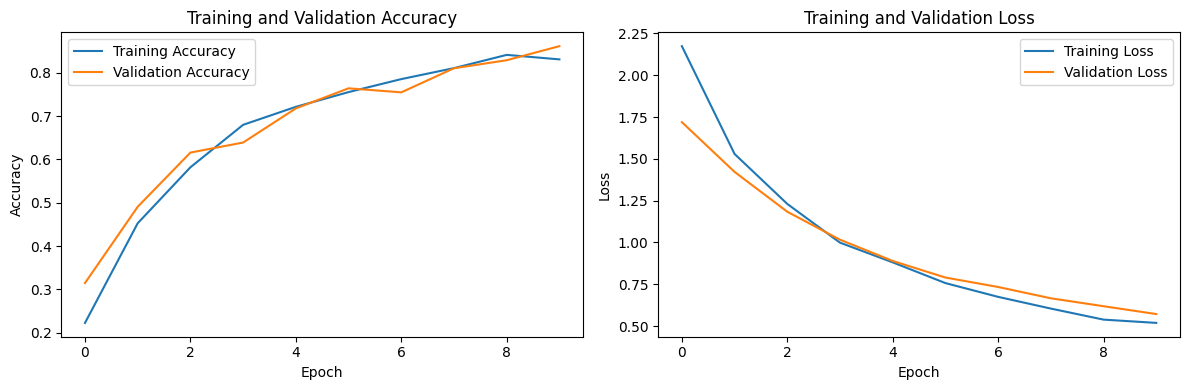

In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

**Reading the curves:**

- Both training and validation accuracy climb **steadily and almost monotonically** from ~22% to the low-80s/high-80s% by epoch 10, with no big oscillations — the model is learning cleanly, and the frozen-base + low learning rate combination is stable.
- Validation accuracy tracks training accuracy closely throughout, and even **edges slightly above it** by the final epochs (~86% val vs ~83% train). This is not a red flag here — it's the expected effect of applying dropout and heavy augmentation only to the training set, which makes training a harder task than plain validation.
- Neither curve had clearly plateaued by epoch 10 — both were still improving. That's a strong signal that **the model was cut off before convergence**: a longer run (or fine-tuning, see recommendations) likely has room to squeeze out more accuracy from this same architecture and data.
- Loss curves mirror the accuracy story: both fall steadily, validation loss ending *below* training loss (0.57 vs 0.52 is close — no overfitting gap visible yet).

### Model Evaluation on Test Data

Now, let's evaluate the trained model on the `test_ds` to assess its generalization performance.

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluate the model on the test dataset
loss, accuracy = model.evaluate(test_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.7000 - loss: 0.8548
Test Loss: 0.8548
Test Accuracy: 0.7000


## 8. Classification Report & Per-Class Analysis

Overall accuracy hides a lot — a model can score 70% while being nearly useless on two or three denominations. This is the real diagnostic step for a baseline.


In [ ]:
# Get true labels and predicted labels from the test dataset
y_true = []
y_pred = []

for images, labels in test_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    predictions = model.predict(images)
    y_pred.extend(np.argmax(predictions, axis=1))

# Get class names from the training dataset
class_names = train_ds.class_names

# Generate classification report
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:")
print(report)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Classification Report:
              precision    recall  f1-score   support

          10       1.00      0.56      0.71         9
         100       0.85      0.92      0.88        12
        1000       1.00      0.92      0.96        12
          20       0.50      0.08      0.14        12
         200       0.59      0.83      0.69        12
           5       0.88      0.78      0.82         9
          50       0.43      1.00      0.60        12
         500       1.00      0.50      0.67        12

    accuracy                           0.70        90
   macro avg       0.78      0.70      0.68        90
weighted avg       0.77      0.70      0.68        90



**Per-class breakdown** (support = number of test images per class, 9–12 each):

| Denomination | Precision | Recall | F1 | Read |
|---|---|---|---|---|
| ₦1000 | 1.00 | 0.92 | 0.96 | Excellent — the model's most reliable class |
| ₦100 | 0.85 | 0.92 | 0.88 | Strong |
| ₦10 | 1.00 | 0.56 | 0.71 | Precise when it predicts ₦10, but misses almost half the actual ₦10 notes |
| ₦5 | 0.88 | 0.78 | 0.82 | Solid |
| ₦500 | 1.00 | 0.50 | 0.67 | Never wrongly predicted, but only catches half the true ₦500 notes |
| ₦200 | 0.59 | 0.83 | 0.69 | Recalls most ₦200 notes, but over-predicts this class (false positives) |
| **₦50** | **0.43** | **1.00** | 0.60 | Catches every real ₦50, but is the model's "dumping ground" — lots of other notes get misclassified as ₦50 |
| **₦20** | **0.50** | **0.08** | 0.14 | **Weakest class by far** — only 1 of 12 actual ₦20 notes correctly identified |

**The clear story:** ₦20 is the model's biggest failure — it almost never gets predicted correctly, and given ₦50's perfect recall + poor precision (1.00 precision→ wait, ₦50 precision is 0.43, meaning many *other* notes are being called "₦50"), the most likely failure mode is the model confusing ₦20 notes for ₦50 (and to a lesser extent ₦200). This is a common pattern for lower-denomination Naira notes, which can be visually similar in overall color/size at the resolution and augmentation strength used here — and it's a great candidate for targeted extra training data (see recommendations).

₦10 and ₦500 both show the *opposite* pattern — perfect precision but weak recall — meaning the model is cautious about predicting these classes, so it under-calls them in favor of visually similar neighbors, rather than confusing them outward.


### Confusion Matrix

A confusion matrix will help us visualize how well the model classified each denomination and identify any common misclassifications.

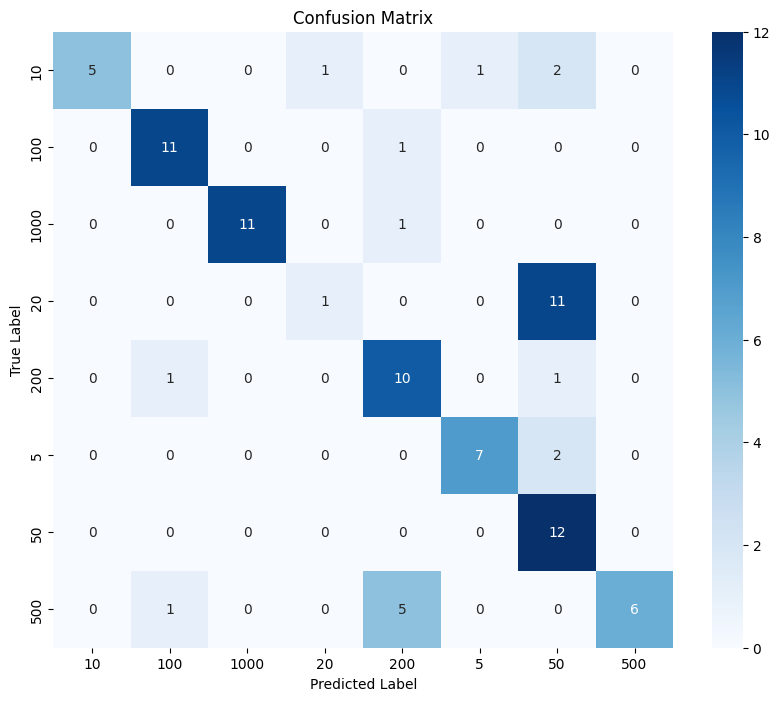

In [ ]:
# Generate confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

The matrix confirms the classification-report story visually: the ₦20 row is scattered across several predicted columns instead of concentrating on the diagonal, and the ₦50 and ₦200 columns pick up stray predictions from other true classes. The strong classes (₦1000, ₦100, ₦5) show tightly concentrated diagonal cells with little bleed into neighboring classes.


## 10. Overall Conclusion & Recommendations

### Conclusion

This baseline — MobileNetV2 with a frozen ImageNet base and a small trainable head, trained for 10 epochs on ~1,736 Kaggle images — reached **70.0% test accuracy** (test loss 0.8548). Training and validation curves were both still climbing at epoch 10 with no overfitting gap, and the failure pattern is concentrated rather than diffuse: the model is genuinely strong on ₦1000, ₦100, and ₦5, and genuinely weak specifically on **₦20** (and to a lesser degree ₦50/₦200 confusion). That's a good outcome for a baseline — it tells us the architecture is viable and gives a precise target for improvement, rather than a model that's uniformly mediocre everywhere.

### Recommendations for the Next Iteration

1. **Targeted data collection (highest priority).** Since you're already planning to add self-captured images, prioritize **₦20 and ₦50 notes** specifically — more examples across lighting conditions, angles, and note conditions (worn/new) for exactly the classes the confusion matrix flags. Generic across-the-board data collection will help less than targeted collection here.
2. **Fine-tuning the base model.** Unfreeze the top layers of MobileNetV2 (not all of it) and continue training with a very small learning rate (e.g. `1e-5`). Frozen-base transfer learning caps how well the model can adapt ImageNet-generic features to note-specific texture and color cues — fine-tuning is the natural next step once more data is available to support it without overfitting.
3. **Train longer / add early stopping.** Both curves were still improving at epoch 10 — rerun with more epochs and an `EarlyStopping` callback (monitoring `val_loss`) to find the natural convergence point rather than cutting off arbitrarily.
4. **Expand the test set.** With 9–12 images per class, individual metrics are noisy. A larger, held-out test set (especially with self-captured images mixed in) will give a much more trustworthy read on real-world performance.
5. **Hyperparameter tuning.** Once the data situation improves, sweep learning rate, batch size, and dropout rate — the current values were reasonable defaults, not tuned.
6. **Error analysis on the actual misclassified ₦20 images.** Pull the specific misclassified test images and inspect them directly — this is often the fastest way to learn *why* two denominations get confused (color similarity under certain lighting, similar note size, watermark visibility, etc.), and can directly guide what kind of new captured data to prioritize.
7. **Ensembling (later-stage).** Once individual models are solid, combining predictions from a couple of architectures (e.g. MobileNetV2 + EfficientNet) could add robustness — but this is a refinement for after the core data/fine-tuning issues are addressed, not before.
8. **Deployment-readiness.** MobileNetV2 was chosen partly for edge-friendliness — once accuracy targets are met, quantization (e.g. TFLite conversion with post-training quantization) will matter for running this on a note-counting device or phone.

**Bottom line:** the baseline validates the approach (transfer learning + MobileNetV2 is a reasonable foundation) and gives a precise, evidence-backed to-do list — ₦20 data collection and fine-tuning are the two levers most likely to move the needle before the next evaluation round.
